# Problem 1.1

In [ ]:
import numpy as np

K = np.array([
    [-1, 1, 0, 0],
    [-1, 0, 1, 0],
    [0, 1, -1, 0],
    [-1, 0, 0, 1],
])

L_1 = K.T @ K 

print("Laplacian matrix:")
print(L_1)


# define the adjacency matrix of the directed graph
A = np.array([[0, 1, 1, 1],
              [1, 0, 1, 0],
              [1, 1, 0, 0],
              [1, 0, 0, 0]])

# calculate the degree matrix
D = np.array([[3, 0, 0, 0],
              [0, 2, 0, 0],
              [0, 0, 2, 0],
              [0, 0, 0, 1]])

# calculate the Laplacian matrix
L_2 = D - A

print("Adjacency matrix:")
print(A)
print("Degree matrix:")
print(D)
print("Laplacian matrix:")
print(L_2)
print(L_1.all() == L_2.all())
  



Laplacian matrix:
[[ 3 -1 -1 -1]
 [-1  2 -1  0]
 [-1 -1  2  0]
 [-1  0  0  1]]
Adjacency matrix:
[[0 1 1 1]
 [1 0 1 0]
 [1 1 0 0]
 [1 0 0 0]]
Degree matrix:
[[3 0 0 0]
 [0 2 0 0]
 [0 0 2 0]
 [0 0 0 1]]
Laplacian matrix:
[[ 3 -1 -1 -1]
 [-1  2 -1  0]
 [-1 -1  2  0]
 [-1  0  0  1]]
True


# Problem 1.2

In [ ]:
import numpy as np

K = np.array([
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 1, -1, 0],
    [-1, 0, 0, 1],
])

L = K.T @ K 

print("Laplacian matrix:")
print(L)

# compute the eigenvalues
eigvals = np.linalg.eigvals(L)

# define the tolerance for zero eigenvalues


# find the zero eigenvalues
zero_eigvals = eigvals[np.abs(eigvals) < 1]

print("Eigenvalues:")
print(eigvals)
print("Number of Zero eigenvalues:")
print(len((zero_eigvals)) - np.count_nonzero(zero_eigvals))


Laplacian matrix:
[[ 1  0  0 -1]
 [ 0  1 -1  0]
 [ 0 -1  1  0]
 [-1  0  0  1]]
Eigenvalues:
[2. 0. 2. 0.]
Number of Zero eigenvalues:
2


# Problem 2


/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


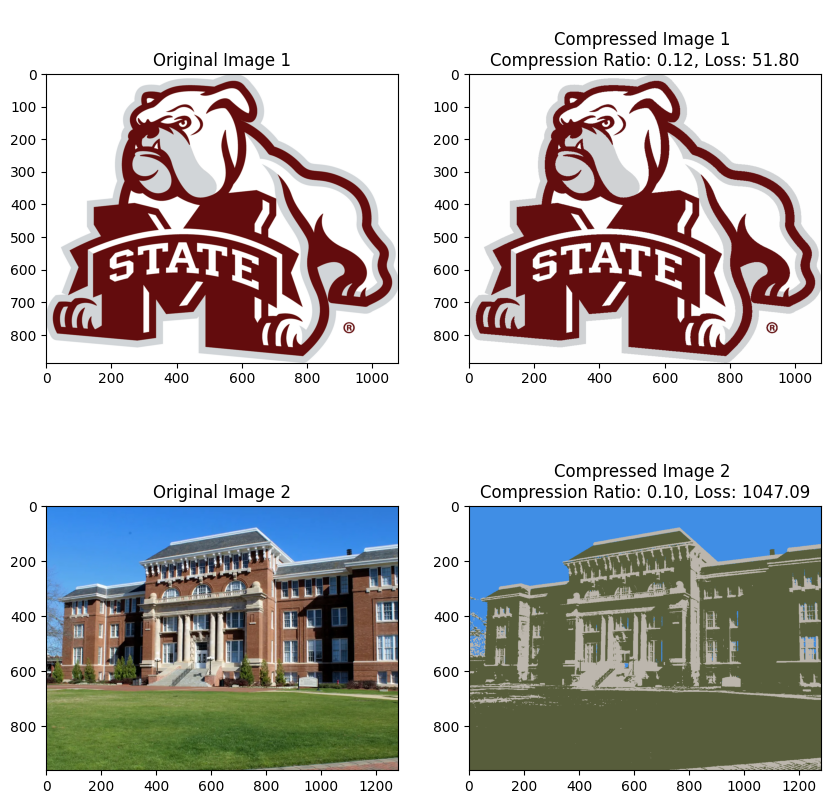

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load the images
image1 = Image.open('hw2_2.png')
image2 = Image.open('building.png')
image1_array = np.array(image1)
image2_array = np.array(image2)

k = 3
rgb = 3

# Flatten the images into a 2D array of pixels
pixel1_array = image1_array.reshape(-1, 3)
pixel2_array = image2_array.reshape(-1, 3)

# k-means clustering on the pixel values
kmeans1 = KMeans(n_clusters=k, random_state=0).fit(pixel1_array)
kmeans2 = KMeans(n_clusters=k, random_state=0).fit(pixel2_array)

# Replace each pixel value with nearest centroid
compressed_pixel1_array = kmeans1.cluster_centers_[kmeans1.labels_]
compressed_pixel2_array = kmeans2.cluster_centers_[kmeans2.labels_]

# Reshape the pixel array back into the original image shape
compressed_image1_array = compressed_pixel1_array.reshape(image1_array.shape)
compressed_image2_array = compressed_pixel2_array.reshape(image2_array.shape)

# Calculate the compression ratio for the images
original_size1 = image1.size[0] * image1.size[1] * rgb
compressed_size1 = compressed_image1_array.size * compressed_image1_array.itemsize
compression_ratio1 = original_size1 / compressed_size1

original_size2 = image1.size[0] * image1.size[1] * rgb
compressed_size2 = compressed_image2_array.size * compressed_image2_array.itemsize
compression_ratio2 = original_size2 / compressed_size2

# Calculate the loss for the images
loss1 = np.mean((image1_array - compressed_image1_array) ** 2)
loss2 = np.mean((image2_array - compressed_image2_array) ** 2)

# Convert the numpy array back into an image and save it
compressed_image1 = Image.fromarray(np.uint8(compressed_image1_array))
compressed_image1.save('compressed_hw2_2.png')

compressed_image2 = Image.fromarray(np.uint8(compressed_image2_array))
compressed_image2.save('compressed_hw_flower.png')

# Plot the original and compressed images
fig, axis = plt.subplots(2, 2, figsize=(10, 10))
axis[0, 0].imshow(image1)
axis[0, 0].set_title('Original Image 1')
axis[0, 1].imshow(compressed_image1)
axis[0, 1].set_title(f'\nCompressed Image 1 \nCompression Ratio: {compression_ratio1:.2f}, Loss: {loss1:.2f}')
axis[1, 0].imshow(image2)
axis[1, 0].set_title('Original Image 2')
axis[1, 1].imshow(compressed_image2)
axis[1, 1].set_title(f'\nCompressed Image 2 \nCompression Ratio: {compression_ratio2:.2f}, Loss: {loss2:.2f}')
plt.show()

# Problem 3

/usr/local/lib/python3.9/dist-packages/sklearn/manifold/_spectral_embedding.py:274: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/manifold/_spectral_embedding.py:274: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/manifold/_spectral_embedding.py:274: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/manifold/_spectral_embedding.py:274: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


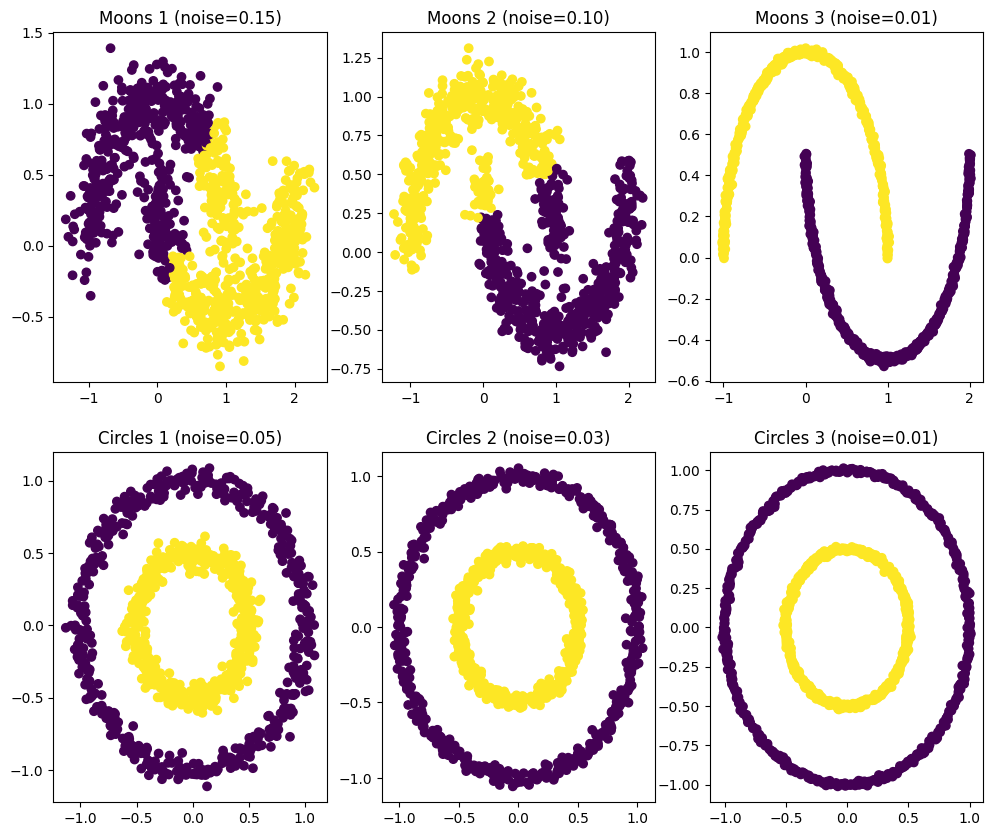

In [2]:
from sklearn.cluster import SpectralClustering
from sklearn.datasets import make_circles, make_moons
import matplotlib.pyplot as plt

# Generate the data
moon_data1 = make_moons(n_samples=1000, noise=0.15)
moon_data2 = make_moons(n_samples=1000, noise=0.10)
moon_data3 = make_moons(n_samples=1000, noise=0.01)
circle_data1 = make_circles(n_samples=1000, noise=0.05, factor=0.5)
circle_data2 = make_circles(n_samples=1000, noise=0.03, factor=0.5)
circle_data3 = make_circles(n_samples=1000, noise=0.01, factor=0.5)

# Perform spectral clustering on the data
clustering = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', assign_labels='kmeans')
labels_moon1 = clustering.fit_predict(moon_data1[0])
labels_moon2 = clustering.fit_predict(moon_data2[0])
labels_moon3 = clustering.fit_predict(moon_data3[0])
labels_circle1 = clustering.fit_predict(circle_data1[0])
labels_circle2 = clustering.fit_predict(circle_data2[0])
labels_circle3 = clustering.fit_predict(circle_data3[0])

# Plot the results
fig, axis = plt.subplots(2, 3, figsize=(12,10))
axis[0, 0].scatter(moon_data1[0][:,0], moon_data1[0][:,1], c=labels_moon1)
axis[0, 0].set_title('Moons 1 (noise=0.15)')
axis[0, 1].scatter(moon_data2[0][:,0], moon_data2[0][:,1], c=labels_moon2)
axis[0, 1].set_title('Moons 2 (noise=0.10)')
axis[0, 2].scatter(moon_data3[0][:,0], moon_data3[0][:,1], c=labels_moon3)
axis[0, 2].set_title('Moons 3 (noise=0.01)')
axis[1, 0].scatter(circle_data1[0][:,0], circle_data1[0][:,1], c=labels_circle1)
axis[1, 0].set_title('Circles 1 (noise=0.05)')
axis[1, 1].scatter(circle_data2[0][:,0], circle_data2[0][:,1], c=labels_circle2)
axis[1, 1].set_title('Circles 2 (noise=0.03)')
axis[1, 2].scatter(circle_data3[0][:,0], circle_data3[0][:,1], c=labels_circle3)
axis[1, 2].set_title('Circles 3 (noise=0.01)')
plt.show()
